In [1]:
from math import sqrt
from typing import Any, cast, override

import astra
import matplotlib.pyplot as plt
import torch
from torch import Tensor
import torch.utils.data

from fun.data.ellipses_dataset import EllipsesDataset
from fun.radon_operator import RadonBackward

ImportError: cannot import name 'override' from 'typing' (/home/aa609734/.conda/envs/FNO-UNet/lib/python3.11/typing.py)

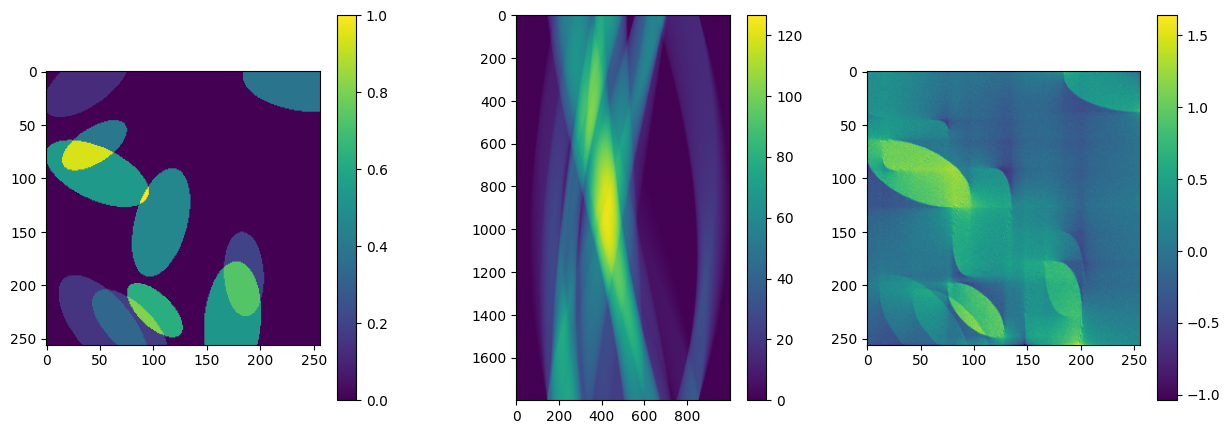

In [ ]:
dataset = EllipsesDataset(1, 256, 10, noise_level=1.0, binary_output=False)
plt.subplots(1, 3, figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(dataset[0]["target"][0].numpy())
plt.colorbar()
plt.subplot(1, 3, 2)
plt.imshow(dataset[0]["input"][0].numpy())
plt.colorbar()
plt.subplot(1, 3, 3)
plt.imshow(cast(Tensor, RadonBackward.apply(dataset[0]["input"], (256, 256), 1000, torch.linspace(0.0, torch.pi, 1800)))[0].numpy())
plt.colorbar()
plt.show()

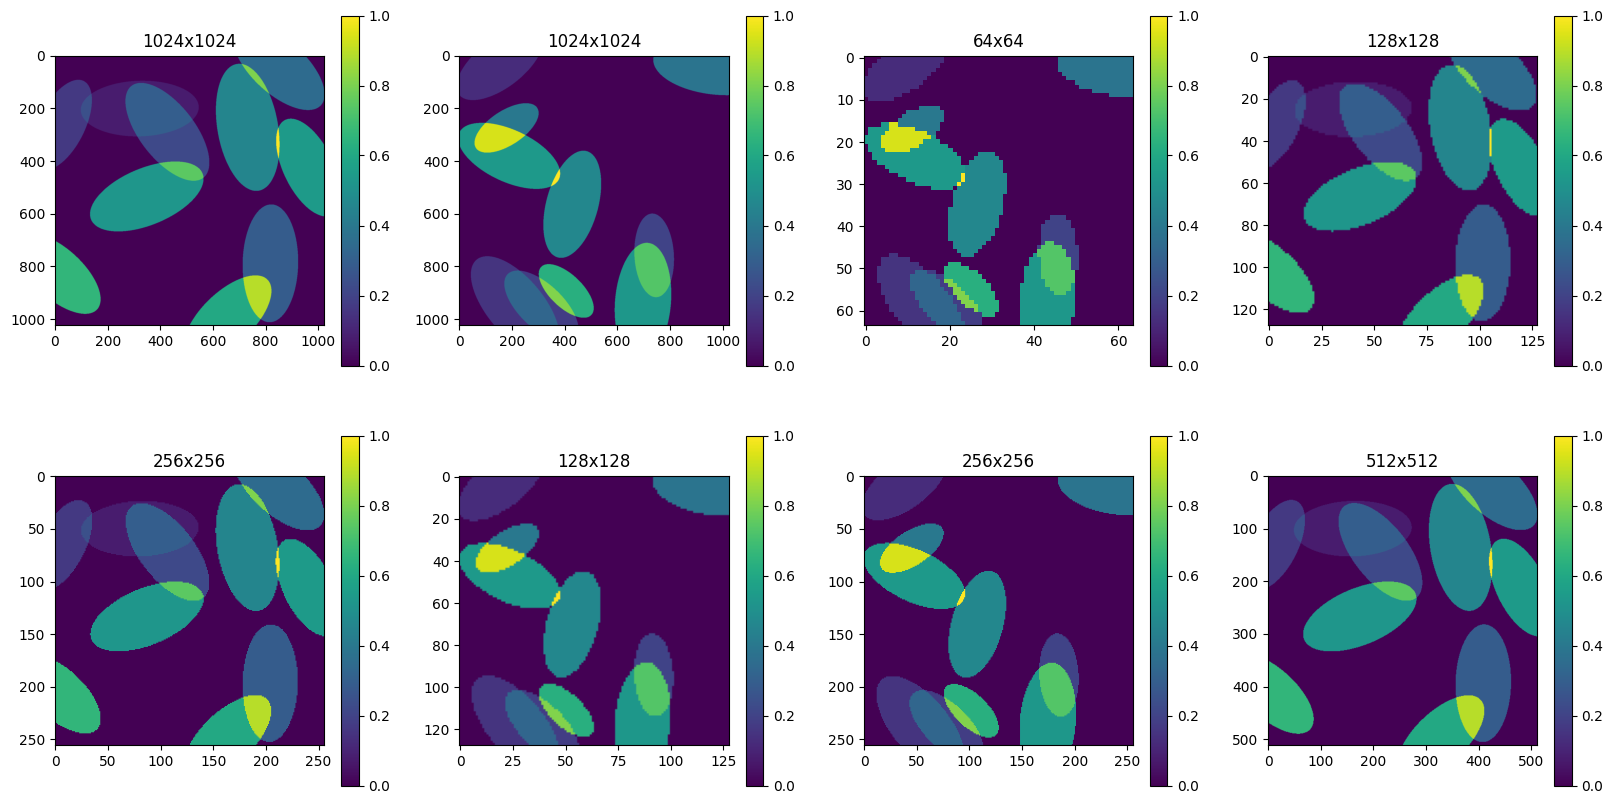

In [ ]:
dataset64 = EllipsesDataset(2, 64, 10, noise_level=1.0, binary_output=False)
dataset128 = EllipsesDataset(2, 128, 10, noise_level=1.0, binary_output=False)
dataset256 = EllipsesDataset(2, 256, 10, noise_level=1.0, binary_output=False)
dataset512 = EllipsesDataset(2, 512, 10, noise_level=1.0, binary_output=False)
dataset1024 = EllipsesDataset(2, 1024, 10, noise_level=1.0, binary_output=False)
dataset = torch.utils.data.ConcatDataset([dataset64, dataset128, dataset256, dataset512, dataset1024])
dataloader_iter = iter(torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=True))

plt.subplots(2, 4, figsize=(20, 10))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    image = next(dataloader_iter)["target"][0,0].numpy()
    plt.title(f"{image.shape[0]}x{image.shape[1]}")
    plt.imshow(image)
    plt.colorbar()
plt.show()